# Uplift模型、评估与预算

读取已经训练的实际模型结果；核心训练方法见src/models.py。所有选择先在验证集锁定，再看测试结果。

In [1]:
from pathlib import Path
import sys
ROOT = Path.cwd()
if ROOT.name == 'notebooks': ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
import pandas as pd
from IPython.display import display, Image
from src.experiment import difference_ci
from src.metrics import gain_curve
from src.utils import read_json
print('项目根目录:', ROOT)

项目根目录: D:\resume\projects\criteo-uplift-analysis


## 1. S、T、X-Learner
S把处理变量加入响应模型；T分别拟合两个处理组；X利用另一组的响应预测构造效应伪标签。输入只有12个处理前特征。

In [2]:
display(read_json(ROOT/'models/model_selection.json'))
display(pd.read_csv(ROOT/'reports/tables/training_iterations.csv'))
display(pd.read_csv(ROOT/'reports/tables/model_evaluation.csv'))

{'visit': {'model': 's_learner',
  'validation_qini': 0.004240624081934274,
  'selection_set': 'validation',
  'criterion': 'normalized Qini area',
  'primary': True},
 'conversion': {'model': 't_learner',
  'validation_qini': 0.00025285323272892775,
  'selection_set': 'validation',
  'criterion': 'normalized Qini area',
  'primary': False}}

,outcome,component,best_iteration,n_features,objective
0,visit,s,111,13,binary
1,visit,t0,74,12,binary
2,visit,t1,111,12,binary
3,visit,response,113,12,binary
4,visit,x0,12,12,regression
5,visit,x1,75,12,regression
6,conversion,s,59,13,binary
7,conversion,t0,34,12,binary
8,conversion,t1,63,12,binary
9,conversion,response,68,12,binary


,outcome,model,split,n,auuc,qini,gain_at_20,incremental_per_10000_at_20,selected_on_validation,response_roc_auc,response_pr_auc,qini_ci_lower,qini_ci_upper
0,visit,s_learner,validation,600000,0.009506,0.004241,0.009248,92.484678,True,NaN,NaN,NaN,NaN
1,visit,t_learner,validation,600000,0.008517,0.003251,0.008513,85.134395,False,NaN,NaN,NaN,NaN
2,visit,response,validation,600000,0.009744,0.004478,0.009844,98.438597,False,0.944753,0.499898,NaN,NaN
3,visit,x_learner,validation,600000,0.009186,0.003920,0.009263,92.630884,False,NaN,NaN,NaN,NaN
4,visit,s_learner,test,600000,0.008996,0.003729,0.008959,89.589186,True,NaN,NaN,0.003202,0.004259
5,visit,t_learner,test,600000,0.008362,0.003095,0.008320,83.199593,False,NaN,NaN,0.002469,0.003675
6,visit,response,test,600000,0.009759,0.004493,0.009728,97.281637,False,0.944789,0.503592,0.003917,0.005059
7,visit,x_learner,test,600000,0.008883,0.003616,0.009021,90.206359,False,NaN,NaN,0.003022,0.004204
8,conversion,s_learner,validation,600000,0.000729,0.000173,0.000734,7.336559,False,NaN,NaN,NaN,NaN
9,conversion,t_learner,validation,600000,0.000809,0.000253,0.000773,7.728901,True,NaN,NaN,NaN,NaN


## 2. 复核处理比例校正的测试集曲线
G(q)=Σ(top-q)Y[T/p−(1−T)/(1−p)]/N；p取整个评估集的处理比例，不能在每个Top-K子集重估后混用。

测试Qini: 0.0037289867909745668 测试AUUC: 0.008995703817167943
100%预算端点: 0.010533434052386756


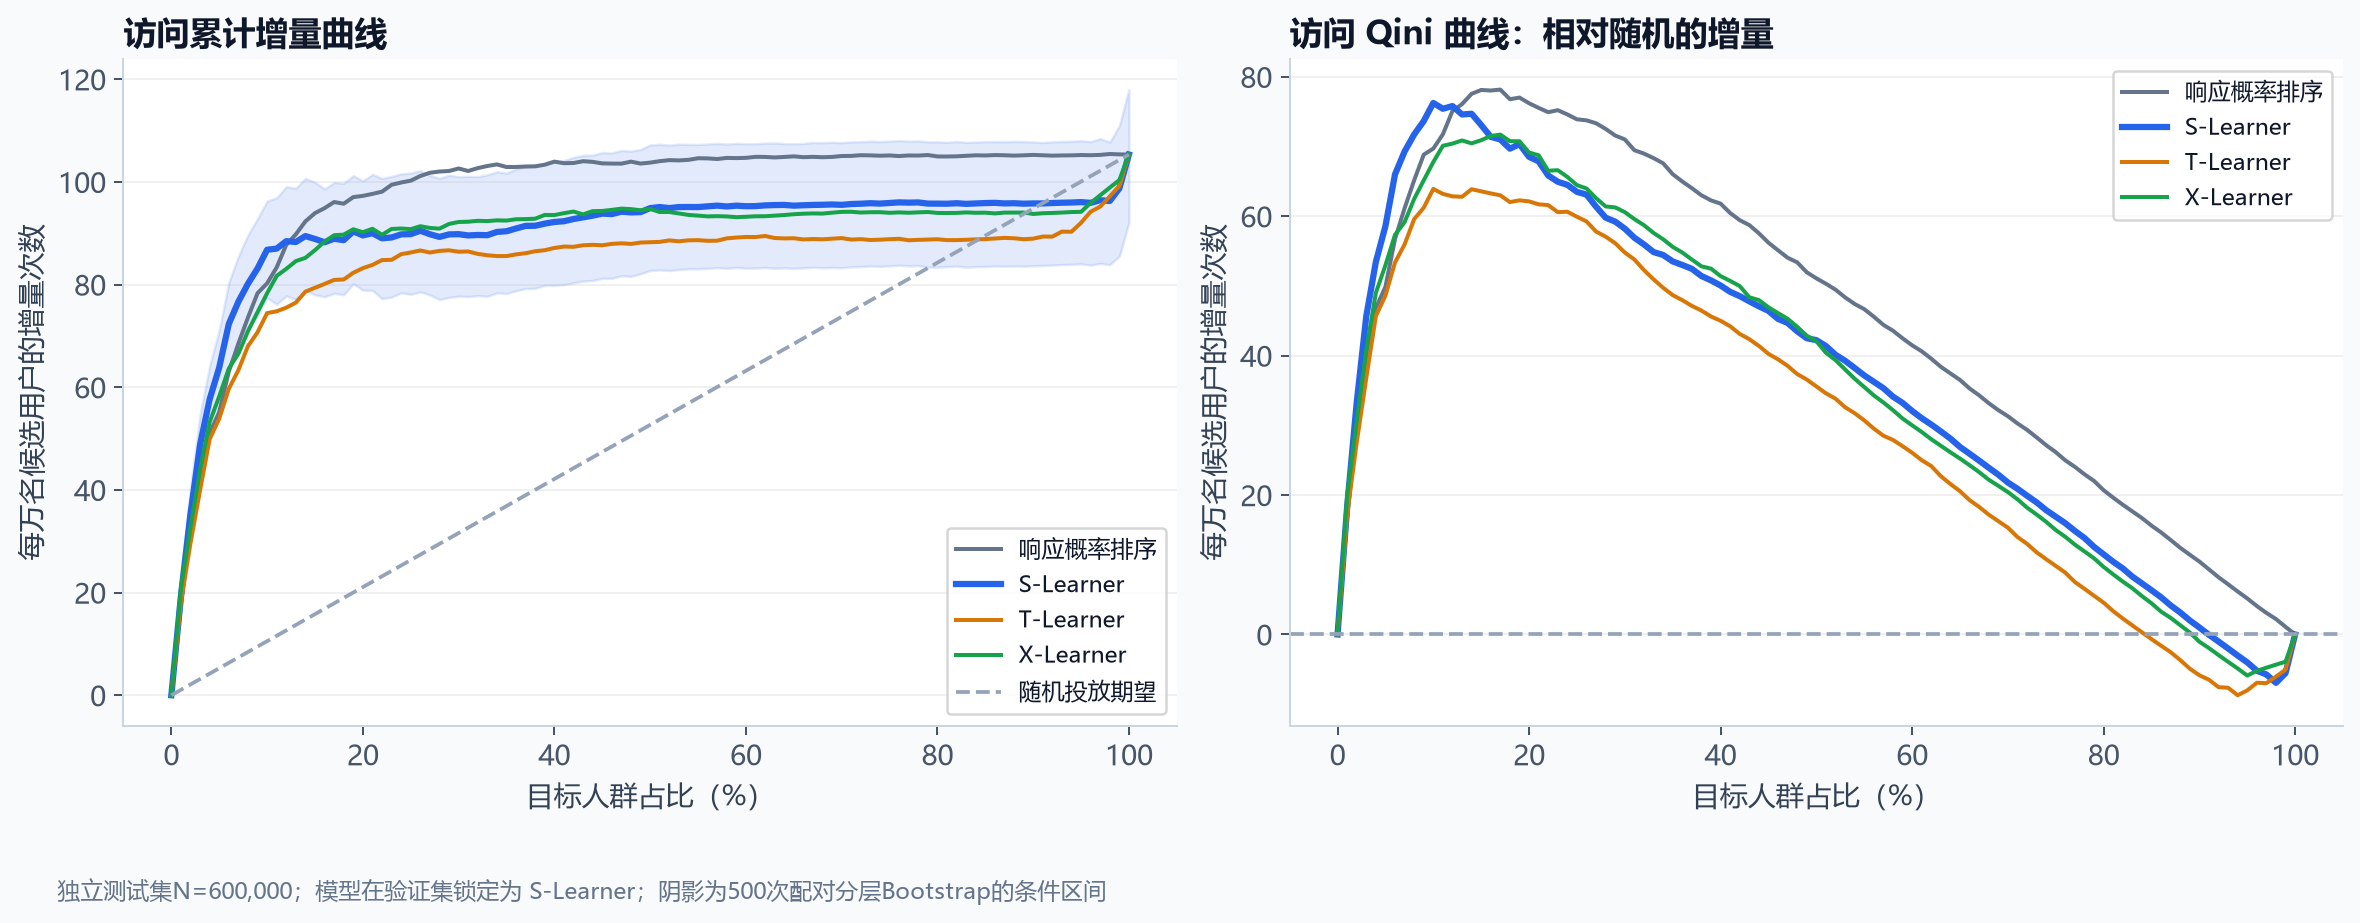

In [3]:
pred = pd.read_parquet(ROOT/'data/processed/predictions_visit.parquet')
pred = pred.loc[pred.split == 'test']
selected = read_json(ROOT/'models/model_selection.json')['visit']['model']
curve = gain_curve(pred.visit.to_numpy(), pred.treatment.to_numpy(), pred['score_'+selected].to_numpy(), pred.row_id.to_numpy())
print('测试Qini:', curve['qini'], '测试AUUC:', curve['auuc'])
print('100%预算端点:', curve['gain'][-1])
display(Image(filename=str(ROOT/'reports/figures/03_visit_uplift_curves.png')))

## 3. 预设20%预算的策略比较
随机策略使用期望表现，所有策略在同一预算下比较。全量投放只作为100%成本参照。

,outcome,strategy,model,budget_fraction,evaluation_n,targeted_n,gain,incremental_per_10000,ci_lower_per_10000,ci_upper_per_10000,vs_random_per_10000,vs_random_ci_lower_per_10000,vs_random_ci_upper_per_10000,incremental_per_1000_targeted,normalized_cost_per_10000,default_budget
5,visit,random,none,0.2,600000,120000,0.002107,21.066868,18.408437,23.597392,0.000000,0.000000,0.000000,10.533434,2000,True
13,visit,response,response,0.2,600000,120000,0.009728,97.281637,84.581697,109.834487,76.214769,66.112667,86.553635,48.640819,2000,True
21,visit,uplift,s_learner,0.2,600000,120000,0.008959,89.589186,78.901074,100.213956,68.522318,59.915494,77.122345,44.794593,2000,True


,outcome,model,budget_fraction,paired_vs_random_ci_lower,paired_vs_random_ci_upper,paired_vs_response_ci_lower,paired_vs_response_ci_upper,n_bootstrap,interval_scope
0,visit,s_learner,0.2,0.005992,0.007712,-0.001322,-0.000150,500,conditional_on_fitted_models_and_fixed_topK_masks
1,visit,t_learner,0.2,0.005294,0.007134,-0.002141,-0.000667,500,conditional_on_fitted_models_and_fixed_topK_masks
2,visit,response,0.2,0.006611,0.008655,0.000000,0.000000,500,conditional_on_fitted_models_and_fixed_topK_masks
3,visit,x_learner,0.2,0.006018,0.007852,-0.001437,0.000023,500,conditional_on_fitted_models_and_fixed_topK_masks
4,conversion,s_learner,0.2,0.000363,0.000847,-0.000313,-0.000032,500,conditional_on_fitted_models_and_fixed_topK_masks
5,conversion,t_learner,0.2,0.000496,0.000953,-0.000240,0.000090,500,conditional_on_fitted_models_and_fixed_topK_masks
6,conversion,response,0.2,0.000539,0.001059,0.000000,0.000000,500,conditional_on_fitted_models_and_fixed_topK_masks


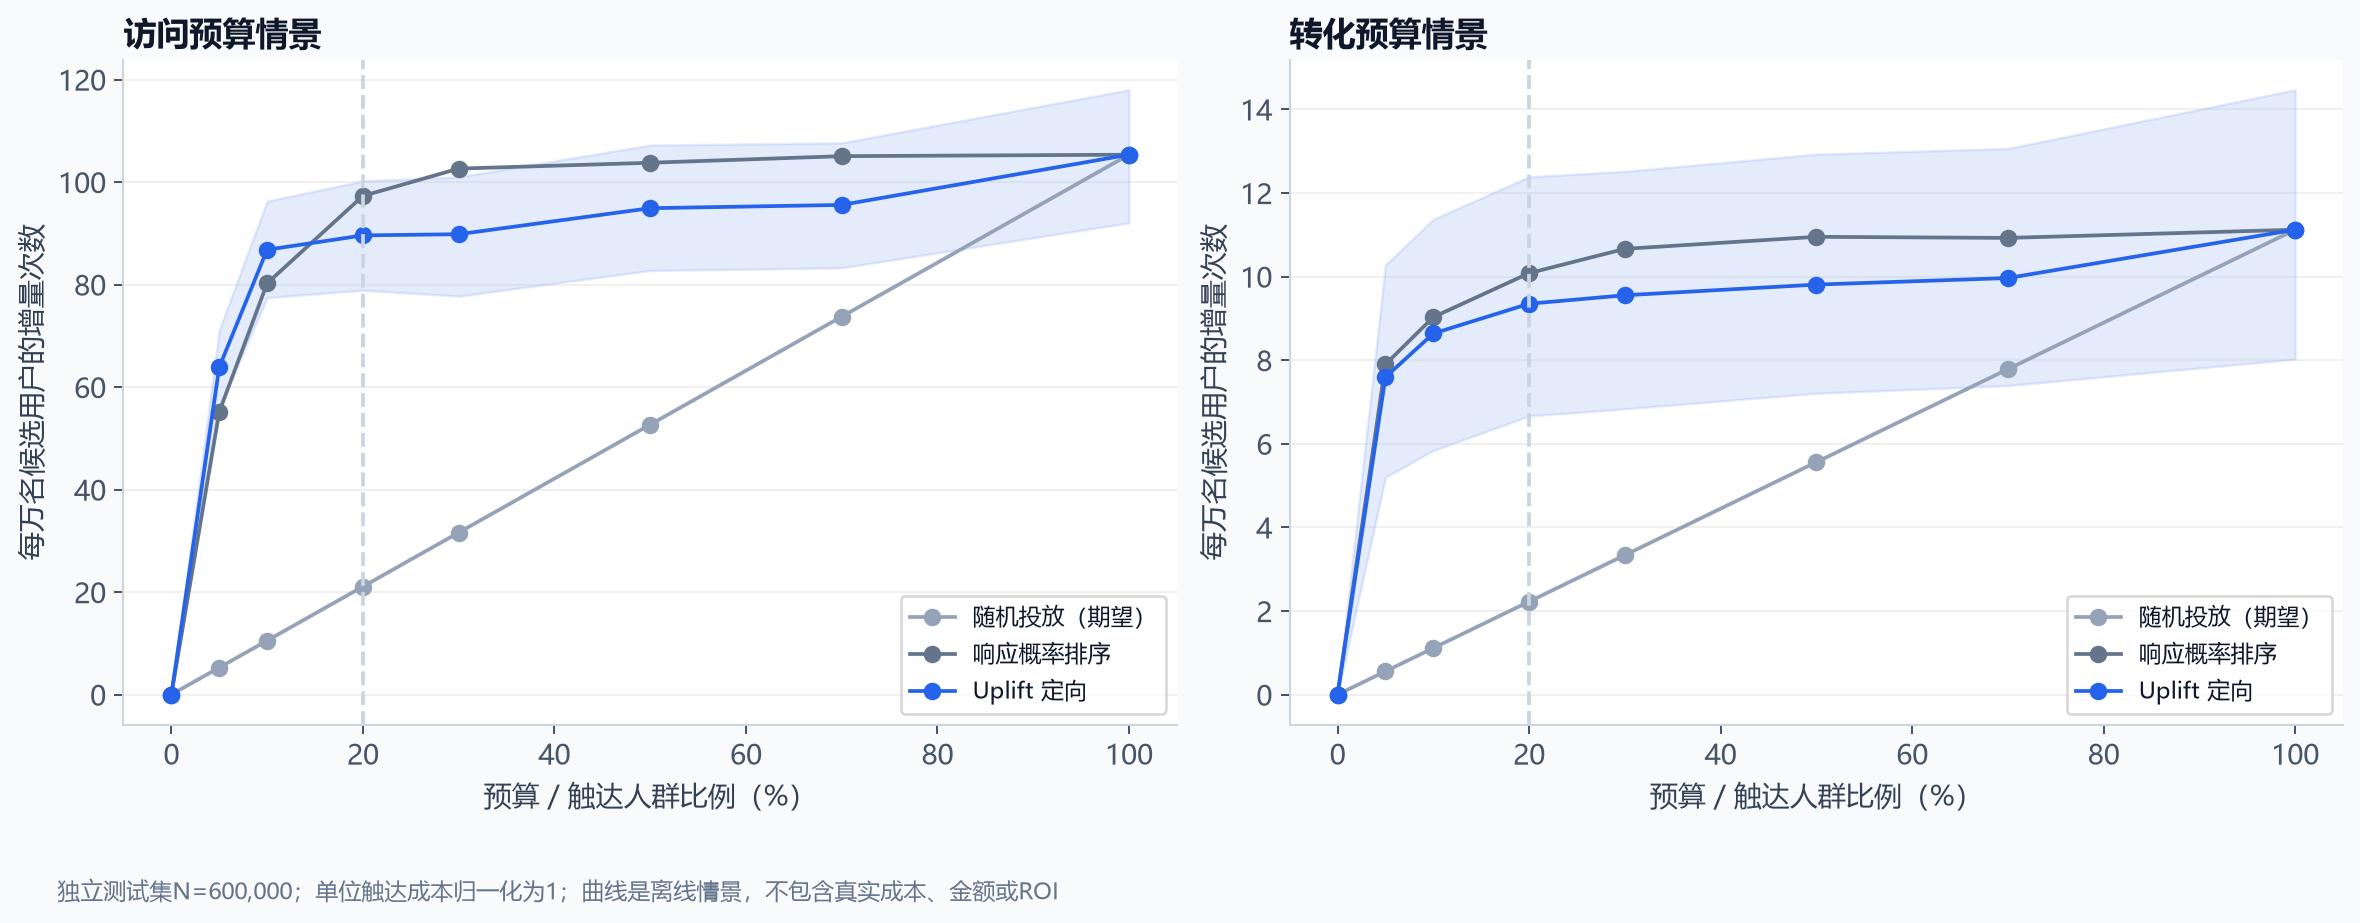

In [4]:
strategies = pd.read_csv(ROOT/'reports/tables/budget_strategies.csv')
display(strategies.loc[(strategies.outcome == 'visit') & (strategies.budget_fraction == .2)])
display(pd.read_csv(ROOT/'reports/tables/paired_uncertainty.csv'))
display(Image(filename=str(ROOT/'reports/figures/05_budget_strategies.png')))

## 4. 条件区间与业务使用
500次处理组内Bootstrap对所有模型使用相同权重；区间以模型及Top-K成员固定为条件，不包括重新训练和全部选择不确定性。匿名十分位人群不是已知的个体反事实类型。